In [139]:
# Import required libraries
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Import the data file using collab
#from google.colab import files
#uploaded = files.upload()


In [140]:

# Read in the insurance dataset
insurance = pd.read_csv("insurance.csv")
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [141]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [142]:
# Check out the insurance dataset
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [143]:
# Turn all categories into numbers
df = pd.get_dummies(insurance,dtype=int)
df.head() # view the converted columns

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0


In [144]:
# Create X & y values
X = df.drop("charges", axis=1)
y = df["charges"]

In [145]:
# View features
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,0,0,1,0,0,0,1
1,18,33.770,1,0,1,1,0,0,0,1,0
2,28,33.000,3,0,1,1,0,0,0,1,0
3,33,22.705,0,0,1,1,0,0,1,0,0
4,32,28.880,0,0,1,1,0,0,1,0,0


In [146]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[1:10,:]

array([[-1.50996545,  0.5096211 , -0.07876719, -0.98959079,  0.98959079,
         0.5074631 , -0.5074631 , -0.56526686, -0.56641788,  1.63579466,
        -0.56641788],
       [-0.79795355,  0.38330685,  1.58092576, -0.98959079,  0.98959079,
         0.5074631 , -0.5074631 , -0.56526686, -0.56641788,  1.63579466,
        -0.56641788],
       [-0.4419476 , -1.30553108, -0.90861367, -0.98959079,  0.98959079,
         0.5074631 , -0.5074631 , -0.56526686,  1.76548098, -0.61132367,
        -0.56641788],
       [-0.51314879, -0.29255641, -0.90861367, -0.98959079,  0.98959079,
         0.5074631 , -0.5074631 , -0.56526686,  1.76548098, -0.61132367,
        -0.56641788],
       [-0.58434998, -0.80765608, -0.90861367,  1.0105187 , -1.0105187 ,
         0.5074631 , -0.5074631 , -0.56526686, -0.56641788,  1.63579466,
        -0.56641788],
       [ 0.48366788,  0.45548642, -0.07876719,  1.0105187 , -1.0105187 ,
         0.5074631 , -0.5074631 , -0.56526686, -0.56641788,  1.63579466,
        -0.566

In [147]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [148]:
# Create training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42) # set random state for reproducible splits

In [149]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1070, 11) (268, 11) (1070,) (268,)


In [150]:
# Set random seed
tf.random.set_seed(42)

# Create a new model (same as model_2)
insurance_model = tf.keras.Sequential([
  tf.keras.layers.Dense(11),
  tf.keras.layers.Dense(1)
])

# Compile the model
insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.SGD(),
                        metrics=['mae'])

In [151]:
# Fit the model
insurance_model.fit(X_train, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13345.5684 - mae: 13345.5684   
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13344.3584 - mae: 13344.3584 
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13342.5684 - mae: 13342.5684 
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13339.5078 - mae: 13339.5078 
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13333.8857 - mae: 13333.8857 
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13323.1904 - mae: 13323.1904 
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13302.5049 - mae: 13302.5049 
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13262.1689 - mae: 13262.1689 
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13183.1738 - mae: 13183.1738 
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13028.1465 - mae: 13028.1465 
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12723.5850 - mae: 12723.5850 
Epoch 12/100
34/3

In [152]:
#save Model
insurance_model.save("insurance_model.keras")

#save scaler
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [153]:
mae_values = insurance_model.history.history['mae']
len(mae_values)

100

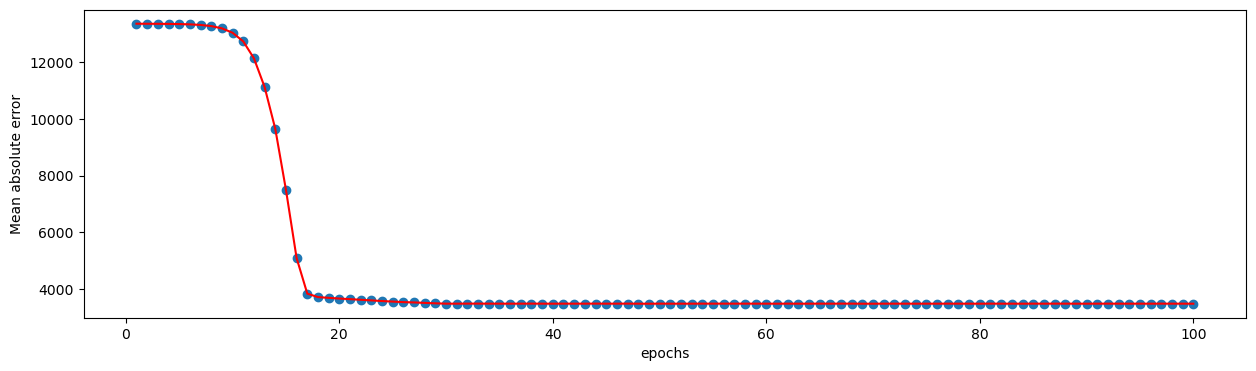

In [154]:
# see the error how it is reduced to minimum times for epoch=5
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 4))
plt.scatter(range(1,101),mae_values)
plt.plot(range(1,101),mae_values,color='red')
plt.ylabel("Mean absolute error")
plt.xlabel("epochs")
plt.show()



In [155]:
# pip list
!pip freeze > requirements.txt



```
`# This is formatted as code`
```

 after looking at the graph , the error is not reducing after sometime....and its became consistent which is not use.

Our model didn't perform very well, let's try a bigger model.

We'll try 3 things:

Increasing the number of layers (2 -> 3).

Increasing the number of units in each layer (except for the output layer).

Changing the optimizer (from SGD to Adam).

In [156]:
# Set random seed
tf.random.set_seed(24)

# Add an extra layer and increase number of units
insurance_model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(11), # 100 units
  tf.keras.layers.Dense(15), # 10 units
  tf.keras.layers.Dense(1) # 1 unit (important for output layer)
])

# Compile the model
insurance_model_2.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(), # Adam works but SGD doesn't
                          metrics=['mae'])

#insurance_model_2.compile(loss=tf.keras.losses.mae,
#                          optimizer=tf.keras.optimizers.SGD(), # Adam works but SGD doesn't
#                          metrics=['mae'])



In [158]:
# Fit the model and save the history (we can plot this)
insurance_model_2.fit(X_train, y_train, epochs=200)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3496.1167 - mae: 3496.1167 
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3495.0876 - mae: 3495.0876 
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3493.9519 - mae: 3493.9519 
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3492.9612 - mae: 3492.9612 
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3491.8525 - mae: 3491.8525 
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3490.8071 - mae: 3490.8071 
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3489.6814 - mae: 3489.6814 
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3488.6387 - mae: 3488.6387 
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3487.5781 - mae: 3487.5781 
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3486.4702 - mae: 3486.4702 
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3485.4558 - mae: 3485.4558 
Epoch 12/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0

In [160]:
# prompt: show me the .compile all hyper parameters

insurance_model_2.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(), # Adam works but SGD doesn't
                          metrics=['mae'])

print(insurance_model_2.compile)


<bound method Trainer.compile of <Sequential name=sequential_13, built=True>>


In [161]:
mae_values = insurance_model_2.history.history['mae']
len(mae_values)

200

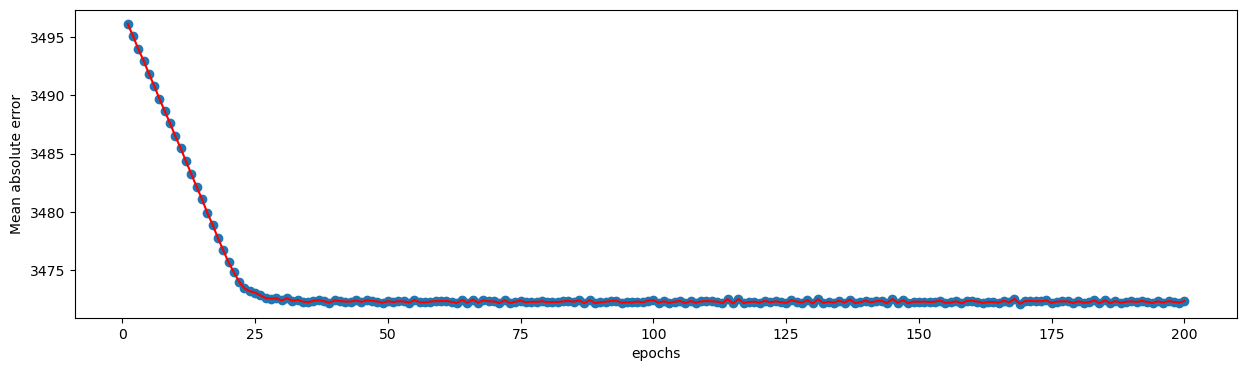

In [162]:
# see the error how it is reduced to minimum times for epoch=5
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 4))
plt.scatter(range(1,201),mae_values)
plt.plot(range(1,201),mae_values,color='red')
plt.ylabel("Mean absolute error")
plt.xlabel("epochs")
plt.show()



In [163]:
insurance_model_2.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3160.3611 - mae: 3160.3611  


[3160.361083984375, 3160.361083984375]

In [ ]:
# prompt: can you give some more optimizer function names for the above code

# - tf.keras.optimizers.RMSprop()
# - tf.keras.optimizers.Adadelta()
# - tf.keras.optimizers.Adagrad()
# - tf.keras.optimizers.Adamax()
# - tf.keras.optimizers.Nadam()
# - tf.keras.optimizers.Ftrl()
